# MZI Delay Arm -- 4-Euler-Bend "Jog" Geometry (Arm Only)

This notebook characterizes a **second, independent way** to build an MZI delay arm,
alongside `07_mzi.ipynb`/`meep_sim/mzi.py`'s own smooth raised-cosine "bump": a delay
arm built from **4 chained `radius_um`-radius Euler bends** plus a variable
straight-waveguide insertion. This is the arm's own 2-port S-parameter
characterization only -- no directional couplers, no full MZI -- following the same
notebook skeleton as `02_bent_waveguide.ipynb`/`meep_sim/bend.py`, the closest
existing analog (also a 2-port device whose interior is non-collinear but whose two
ports sit on the same axis).

**Do not use "Run All."** Work through the notebook step by step, and stop at the
marked checkpoints to actually look at the plots before trusting anything downstream.


## 1. Physical objective

`07_mzi.ipynb`'s delay arm is a single smooth curve (a raised-cosine bump), solved by
bisection to add exactly `delta_L_um` of extra centerline length. This notebook builds
the same *function* -- add a controlled amount of extra path length between two
collinear ports -- a structurally different way: 4 discrete 90-degree bends (Euler by
default) chained into an "up-then-down" detour, with the extra length tuned by two
symmetric straight-waveguide insertions rather than a continuous curve's amplitude.
This is directly comparable to the `circuits/wdm_mux_mzi_lattice_sax.ipynb` notebook's
analytic design, which targeted `delta_L_um=15.0` -- chosen there specifically to land
on `07_mzi.ipynb`'s own already-simulated `delta_L_um=15.0` sweep point. The sweep
below (Section 10) is centered on that same value.

**The geometry.** 4 `gf.components.bend_euler(radius=radius_um, angle=90)` chained via
`.connect()`, alternating handedness so the path goes `+x -> +y -> +x -> -y -> +x` --
an "up-then-down" jog that returns to the same y and heading. Each bend displaces
`(radius_um, +-radius_um)`, so 4 bends span exactly `4*radius_um` in x and net 0 in y:
the two ports stay collinear, the same 2-port convention every other component in this
toolkit uses. A straight-waveguide segment, inserted **symmetrically** right after
bend 1 and right after bend 3 (both while the path is momentarily heading in
`+y`/`-y`), lengthens the jog without changing its x-extent or breaking port
collinearity.

**Why $\Delta L$ matters (governing relations).** In a downstream MZI, this arm's
extra centerline length $\Delta L$ (relative to a plain straight reference arm)
introduces a wavelength-dependent phase difference between the two arms,
$$\Delta\phi(\lambda) = \frac{2\pi n_\mathrm{eff}(\lambda)}{\lambda}\, \Delta L,$$
which sets the interferometer's free spectral range (the wavelength spacing between
transmission peaks),
$$\mathrm{FSR} \approx \frac{\lambda_0^2}{n_g\, \Delta L}$$
($n_g$ the group index, $n_g = n_\mathrm{eff} - \lambda\, dn_\mathrm{eff}/d\lambda$) --
the same relation `circuits/mzi_lattice.py` and `07_mzi.ipynb` both use. This
notebook's own job is only to characterize how much loss and reciprocity error THIS
particular way of adding $\Delta L$ introduces (Sections 5-8 below), not to build
the full interferometer.

## 2. User-adjustable parameters

In [1]:
# pic_toolkit was installed with `pip install -e .` into the `mp` conda environment,
# so it imports directly -- no sys.path manipulation needed.
import inspect

import numpy as np
import matplotlib.pyplot as plt

from pic_toolkit.meep_sim import mzi_arm
from pic_toolkit import checks, viz, sparams, sweep, style

style.apply_style()
%matplotlib inline

params = dict(mzi_arm.DEFAULT_PARAMS)  # a working copy -- edit this dict, not the module default

geometry_params = {
    "wg_width_um": params["wg_width_um"],
    "radius_um": params["radius_um"],
    "bend_type": params["bend_type"],
    "extra_straight_um": params["extra_straight_um"],
    "lead_len_um": params["lead_len_um"],
    "port_offset_um": params["port_offset_um"],
    "source_offset_um": params["source_offset_um"],
}
geometry_params


{'wg_width_um': 0.5,
 'radius_um': 5.0,
 'bend_type': 'euler',
 'extra_straight_um': 0.864,
 'lead_len_um': 3.0,
 'port_offset_um': 1.0,
 'source_offset_um': 0.5}

### Geometry

- **`wg_width_um`** -- waveguide core width, same convention as every other component.
- **`radius_um`** -- the (centerline) radius shared by all 4 bends. `5.0um` here is
  comfortably above `bend.py`'s own measured circular-vs-Euler crossover (~2.0um, see
  `docs/simulation_settings_record.md`), so an Euler bend at this radius is genuinely
  the lower-loss choice, not just the more fashionable one.
- **`bend_type`** -- `"euler"` (default, clothoid curvature) or `"circular"` (constant
  curvature) -- see `bend.py`'s own module docstring for the geometric difference.
- **`extra_straight_um`** -- straight-waveguide length inserted after bend 1 *and*
  after bend 3 (symmetric). The extra centerline length this whole shape adds, versus a
  straight reference spanning the same two ports, is a closed form:
  `delta_L_um = 4*one_bend_length - 4*radius_um + 2*extra_straight_um`, where
  `one_bend_length` is `bend_euler(radius=radius_um, angle=90).info["length"]` (longer
  than the exact quarter-circle `pi/2*radius_um` -- an Euler bend's curvature ramps up
  smoothly rather than jumping straight to `1/radius_um`). At this notebook's defaults
  (`radius_um=5.0`, `bend_type="euler"`), `one_bend_length=8.318um`, so even the bare
  jog (`extra_straight_um=0`) already provides `delta_L_um=13.274um` "for free" --
  `extra_straight_um` is set to `0.864um` by default specifically to land
  `delta_L_um` at exactly `15.0`, matching the SAX-designed lattice-filter notebook.
- **`lead_len_um`** -- straight lead at each of the 2 outer ports, giving the
  source/monitor planes clean straight waveguide to sit on (same role as `bend.py`'s
  `arm_length_um`). It adds equally to the actual path and to the straight-line
  reference above, so it drops out of `delta_L_um` entirely -- confirmed directly:
  `mzi_arm.delta_L_um_from_extra` does not depend on `lead_len_um` at all.
- **`port_offset_um`/`source_offset_um`** -- same roles as `bend.py`'s: how far the
  port (mode monitor) and source planes sit from each end's own bend tangent point.

### Materials

In [2]:
material_params = {
    "core_index": params["core_index"],  # silicon (2D effective index, TE)
    "clad_index": params["clad_index"],  # silicon dioxide
}
material_params


{'core_index': 2.7, 'clad_index': 1.44}

### Wavelengths

In [3]:
wavelength_params = {
    "wl_min_um": params["wl_min_um"],
    "wl_max_um": params["wl_max_um"],
    "n_freq": params["n_freq"],
}
wavelength_params


{'wl_min_um': 1.3, 'wl_max_um': 1.4, 'n_freq': 21}

### Meep units

In [4]:
fcen = 1.0 / ((params["wl_min_um"] + params["wl_max_um"]) / 2)
fwidth = 1.0 / params["wl_min_um"] - 1.0 / params["wl_max_um"]
print(f"center frequency (1/um): {fcen:.4f}   (wavelength {1/fcen:.4f} um)")
print(f"frequency width (1/um):  {fwidth:.4f}")


center frequency (1/um): 0.7407   (wavelength 1.3500 um)
frequency width (1/um):  0.0549


## 3. Geometry construction and permittivity map

`build_gf_component(params)` builds the jog as a gdsfactory `Component`: a lead, 4
bends (alternating mirrored handedness), 2 symmetric straight insertions, and a
second lead, all connected via `.connect()`, then translated so the shape's own tight
bounding box is centered on the origin (never `mp.Simulation`'s `geometry_center` --
see `bend.py`'s own docstring for the documented S-parameter regression that caused).
Here is the actual function used (shown via introspection, so this is exactly the code
that runs):

In [5]:
print(inspect.getsource(mzi_arm.build_gf_component))

def build_gf_component(params: dict):
    """The centered jog component -- gdsfactory geometry translated so its
    own tight bounding box is centered on the origin (see _domain's
    docstring for why, and bend.py's build_gf_component for the identical
    pattern)."""
    import gdsfactory as gf

    dom = _domain(params)
    centered = gf.Component()
    ref = centered.add_ref(dom["raw"])
    ref.move((dom["shift"].x, dom["shift"].y))
    centered.add_ports(ref.ports)
    return centered



### Permittivity map

Built *without running any FDTD timestepping*, exactly as every other component's own
first look at its geometry.

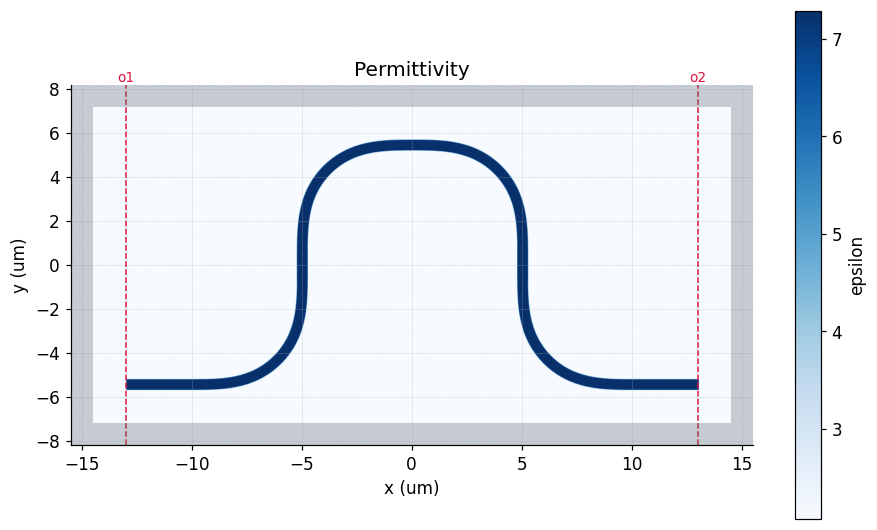

delta_L_um = 15.0000
o1 = Vector3<-13.0, -5.432, 0.0>, o2 = Vector3<13.0, -5.432, 0.0>


In [6]:
perm_map = mzi_arm.get_permittivity_map(params)
dom = mzi_arm._domain(params)
o1, o2 = dom["o1_port"], dom["o2_port"]

fig, ax = plt.subplots(figsize=(10, 6))
viz.plot_permittivity(perm_map.eps, perm_map.extent_um, ax=ax,
                       ports=[(o1.x, o1.y, "o1", "v"), (o2.x, o2.y, "o2", "v")],
                       pml_um=params["dpml_um"])
plt.show()

print(f"delta_L_um = {dom['delta_L_um']:.4f}")
print(f"o1 = {o1}, o2 = {o2}")


> **STOP -- INSPECT THE PERMITTIVITY MAP BEFORE RUNNING FDTD.**
>
> Check, before paying for an expensive simulation:
> - **Shape**: a smooth-looking "hump" connecting two collinear straight leads -- the
>   up-then-down jog described in Section 1, not a self-intersecting or lopsided curve.
> - **Curvature**: every bend's radius is visibly `>= radius_um`, and the waveguide
>   width looks constant everywhere (no narrowing anywhere along the curve).
> - **Port collinearity**: `o1` and `o2` (dashed lines) sit at the same y, both clear
>   of the PML (shaded gray band).
> - **`delta_L_um`** printed above is close to `15.0` (the representative baseline).
>
> If anything looks wrong, fix `params` above and re-run from Section 3 before
> continuing -- an expensive FDTD run on a wrong geometry wastes time and produces
> meaningless S-parameters.

## 4. Source, ports, and FDTD setup -- polarization (mode) convention

**Every eigenmode source/monitor below passes `eig_parity=mp.TE` explicitly** --
`mp.NO_PARITY` does not mean TE (see `CLAUDE.md` Sec 5 / `bend.py`'s own docstring for
the MPB investigation that found this toolkit's cross-sections often favor TM under
`NO_PARITY`). Port `o1`'s lead points `-x` outward (launching into the device means
`+x`); port `o2`'s lead points `+x` outward (launching in means `-x`) -- exactly
`spiral_gds.py`'s own convention for a pair of opposite-facing collinear leads. Here is
the actual function that builds one such simulation:

In [7]:
print(inspect.getsource(mzi_arm._make_simulation))

def _make_simulation(params: dict, launch_from: str, capture_dft: bool):
    """Build one Simulation with an eigenmode source just outside port o1 or
    o2, launching INTO the device -- same convention as every other
    component's own _make_simulation."""
    cell, clad = _cell_and_clad(params)
    dom = _domain(params)
    fcen = 1.0 / ((params["wl_min_um"] + params["wl_max_um"]) / 2)
    fwidth = 1.0 / params["wl_min_um"] - 1.0 / params["wl_max_um"]
    port1_center, port1_size, port2_center, port2_size = _port_planes(params)

    source_off = params["source_offset_um"]
    if launch_from == "o1":
        src_center = mp.Vector3(port1_center.x - source_off, port1_center.y)
        direction_sign = 1
    else:
        src_center = mp.Vector3(port2_center.x + source_off, port2_center.y)
        direction_sign = -1

    source = mp.EigenModeSource(
        src=mp.GaussianSource(frequency=fcen, fwidth=fwidth),
        center=src_center, size=port1_size,
        eig_band=1, eig_parity=

## 5. Baseline FDTD simulation (representative `extra_straight_um`)

`simulate_baseline()` runs this **twice** -- exciting from port `o1`, then from port
`o2` -- to measure the full 2x2 S-matrix from genuinely independent data, rather than
assuming `S12=S21`/`S22=S11` from the shape's own left-right symmetry (checked, not
assumed, in Section 8). This baseline -- at the representative
`extra_straight_um=0.864` (`delta_L_um=15.0`) set in Section 2 -- is validated first,
*before* any sweep, per this project's mandatory workflow.

In [8]:
result = mzi_arm.simulate_baseline(params)
print(f"{len(result.wavelengths_um)} wavelength points, "
      f"{result.wavelengths_um.min():.4f}-{result.wavelengths_um.max():.4f} um")
print(f"delta_L_um = {result.sim_params['delta_L_um']:.4f}")


21 wavelength points, 1.3017-1.4020 um
delta_L_um = 15.0000


## 6. Electromagnetic field visualization -- polarization convention

**Same project convention as every other component: TE -> visualize Ez, TM -> visualize
Hz.** `_run_one_direction` captures both `Ez` and `Hz` and picks whichever actually
dominates -- printed below, don't assume Ez just because TE was forced.

dominant field component: Hz


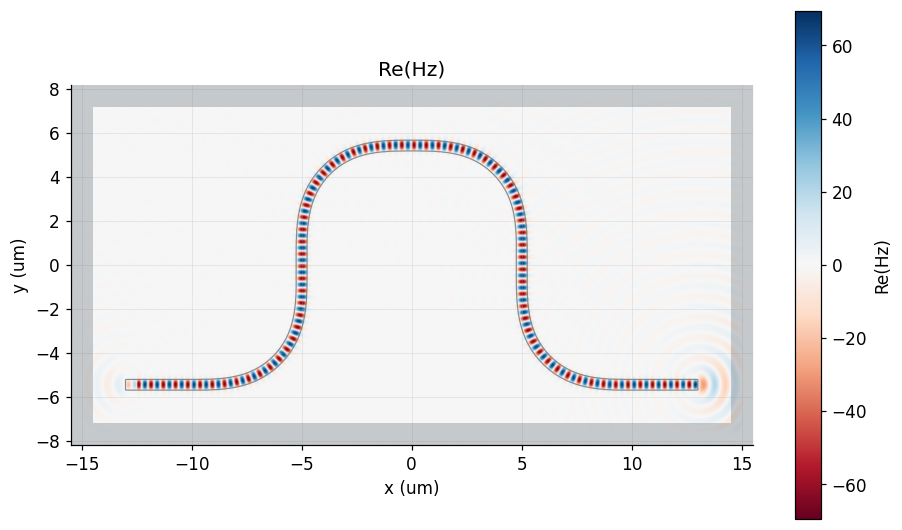

In [9]:
fs = result.field_snapshot
print(f"dominant field component: {fs.component}")

fig, ax = plt.subplots(figsize=(10, 6))
viz.plot_field(fs.field, fs.eps, fs.extent_um, component=fs.component, ax=ax, pml_um=result.sim_params["dpml_um"])
plt.show()


**What a physically reasonable field should show:** the field entering at `o1`,
following the jog smoothly through all 4 bends, and exiting at `o2` -- mostly confined
to the core along the whole path, with some radiation into the cladding concentrated at
the outer wall of each turn (a finite-radius bend is not perfectly adiabatic; that
radiation is exactly what Section 7-8's `S21`/energy-conservation numbers will
quantify).

> **STOP -- INSPECT THE ELECTROMAGNETIC FIELD BEFORE CONTINUING.**
>
> If the field looks scattered or diffuse everywhere rather than following a
> recognizable path from `o1` through all 4 bends to `o2`, the S-parameters extracted
> next will be meaningless regardless of how "correct" the numbers look.

## 7. S-parameters

The full complex 2x2 S-matrix is computed (Section 5) and used in the sanity checks
(Section 8) below.

In [10]:
for key in ["11", "12"]:
    s = result.s_matrix[key]
    i_mid = len(s) // 2
    print(f"S{key}: |S|^2={np.abs(s[i_mid])**2:.4f}  phase={np.angle(s[i_mid]):.3f} rad  "
          f"(at wavelength={result.wavelengths_um[i_mid]:.4f} um)")

s21p_mid = np.abs(result.s_matrix["21"][len(result.s_matrix["21"]) // 2]) ** 2
print(f"S21 (transmission) at mid-band: |S21|^2={s21p_mid:.4f}  "
      f"insertion loss={-10 * np.log10(s21p_mid):.3f} dB")


S11: |S|^2=0.0604  phase=0.603 rad  (at wavelength=1.3500 um)
S12: |S|^2=0.9957  phase=1.429 rad  (at wavelength=1.3500 um)
S21 (transmission) at mid-band: |S21|^2=0.9955  insertion loss=0.020 dB


**Magnitude and phase, versus wavelength:**

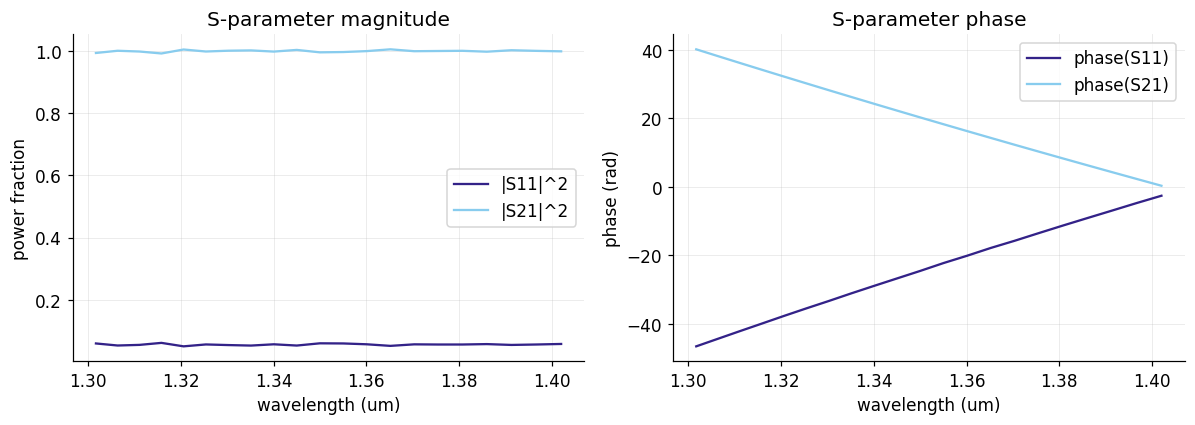

In [11]:
fig = viz.plot_sparams(result.wavelengths_um, result.s_matrix, pairs=("11", "21"))
plt.show()


## 8. Sanity checks

- **Energy conservation**: `|S11|^2 + |S21|^2 <= 1` (and the same for port 2), within
  `max_loss_fraction` of a real loss channel -- genuine bend radiation from 4 turns,
  not simulation error.
- **Passivity**: no `|S_ij|` may exceed 1.
- **Reciprocity**: `S12 = S21`, checked from two *independently measured* runs
  (Section 5).

In [12]:
ENERGY_TOL = 0.10
RECIPROCITY_TOL = 0.10
PASSIVITY_TOL = 0.02
MAX_LOSS_FRACTION = 0.15

validation = checks.run_all_checks(
    result.s_matrix,
    energy_tol=ENERGY_TOL,
    reciprocity_tol=RECIPROCITY_TOL,
    passivity_tol=PASSIVITY_TOL,
    max_loss_fraction=MAX_LOSS_FRACTION,
)

import json
print(json.dumps(validation, indent=2))
assert validation["passed"], "Baseline failed validation -- do not proceed to the sweep."


{
  "energy_conservation": {
    "max_deviation_port1": 0.05741631065099817,
    "max_deviation_port2": 0.06677814900945256,
    "max_deviation": 0.06677814900945256,
    "max_loss_fraction_allowed": 0.15,
    "tolerance": 0.1,
    "passed": true
  },
  "reciprocity": {
    "max_diff_s12_s21": 0.00018382272962338573,
    "max_diff_s11_s22": 0.02201076218083152,
    "max_diff": 0.02201076218083152,
    "tolerance": 0.1,
    "passed": true
  },
  "passivity": {
    "max_magnitude": 1.0027142771267619,
    "tolerance": 0.02,
    "passed": true
  },
  "passed": true
}


## 9. Save baseline artifact

Same format as every other component: `.npz` (numeric arrays) + `.json` (metadata)
sidecar pair, via the shared `sparams.py`.

In [13]:
from pathlib import Path

artifact_stem = Path("../data/sparams/mzi_arm/baseline/mzi_arm_baseline")

metadata = {
    "component": "mzi_arm",
    "geometry_params": {k: result.sim_params[k] for k in
        ["wg_width_um", "radius_um", "bend_type", "extra_straight_um", "lead_len_um",
         "port_offset_um", "source_offset_um"]},
    "material_params": {k: result.sim_params[k] for k in ["core_index", "clad_index"]},
    "delta_L_um": result.sim_params["delta_L_um"],
    "meep_resolution": result.sim_params["resolution"],
    "meep_version": result.sim_params["meep_version"],
    "python_version": result.sim_params["python_version"],
    "creation_date": result.sim_params["creation_date"],
    "validation": validation,
}
sparams.save_artifact(artifact_stem, result.wavelengths_um, result.freqs, result.s_matrix,
                       result.port_names, metadata)
print(f"Saved baseline artifact: {artifact_stem}.npz / .json")


Saved baseline artifact: ../data/sparams/mzi_arm/baseline/mzi_arm_baseline.npz / .json


---

## 10. `delta_L_um` sweep

**The baseline above has been inspected and validated -- only now do we sweep.**
`sweep.grid_sweep()` reuses the exact same `simulate_baseline()` function as the
baseline above, saving one artifact (npz+json) per swept point under
`../data/sparams/mzi_arm/sweep/`.

The swept targets are given directly in **`delta_L_um`** (the quantity that actually
matters), converted to `extra_straight_um` via `mzi_arm.extra_straight_um_for_delta_L`
-- and chosen specifically to **bracket and include `15.0`**, the SAX-designed
lattice-filter notebook's `delta_L_um`, not just approach it. All targets are safely
above this geometry's own floor (`13.274um` at these `radius_um`/`bend_type`
defaults) -- a target below that floor would raise a clear `ValueError` rather than
silently clamping.

Tolerances below are deliberately loose, for the same reason as Section 8 --
`max_loss_fraction` must be wide enough to cover the sweep's longest, most-attenuated
point.

In [14]:
SWEEP_CHECK_KWARGS = dict(energy_tol=0.15, reciprocity_tol=0.15, passivity_tol=0.05, max_loss_fraction=0.30)

DELTA_L_SWEEP_UM = [14.0, 15.0, 17.5, 20.0, 25.0, 30.0]  # brackets and includes 15.0 (the SAX design point)
EXTRA_STRAIGHT_SWEEP_UM = [mzi_arm.extra_straight_um_for_delta_L(dl, params) for dl in DELTA_L_SWEEP_UM]
print(list(zip(DELTA_L_SWEEP_UM, [round(e, 4) for e in EXTRA_STRAIGHT_SWEEP_UM])))

sweep_rows = sweep.grid_sweep(
    simulate_fn=mzi_arm.simulate_baseline,
    base_params=params,
    param_grid={"extra_straight_um": EXTRA_STRAIGHT_SWEEP_UM},
    artifact_dir=Path("../data/sparams/mzi_arm/sweep"),
    component_name="mzi_arm",
    check_kwargs=SWEEP_CHECK_KWARGS,
)
n_passed = sum(row["validation_passed"] for row in sweep_rows)
print(f"delta_L sweep: {n_passed}/{len(sweep_rows)} points within the (loose) sweep tolerance")
sweep.save_manifest(sweep_rows, Path("../data/sparams/mzi_arm/sweep/manifest.csv"))


[(14.0, 0.364), (15.0, 0.864), (17.5, 2.114), (20.0, 3.364), (25.0, 5.864), (30.0, 8.364)]
[1/6  16%] running mzi_arm (extra_straight_um=0.36400000000000077) ...


[2/6  33%] running mzi_arm (extra_straight_um=0.8640000000000008) ...


[3/6  50%] running mzi_arm (extra_straight_um=2.1140000000000008) ...


[4/6  66%] running mzi_arm (extra_straight_um=3.3640000000000008) ...


[5/6  83%] running mzi_arm (extra_straight_um=5.864000000000001) ...


[6/6  100%] running mzi_arm (extra_straight_um=8.364) ...


delta_L sweep: 6/6 points within the (loose) sweep tolerance


## 11. Visualization

Transmission and insertion loss **vs. `delta_L_um`** (not wavelength this time, since
the sweep variable is length) at the center wavelength, plus reciprocity across the
sweep -- directly answering whether more bends/length introduce any significant loss or
symmetry problem.

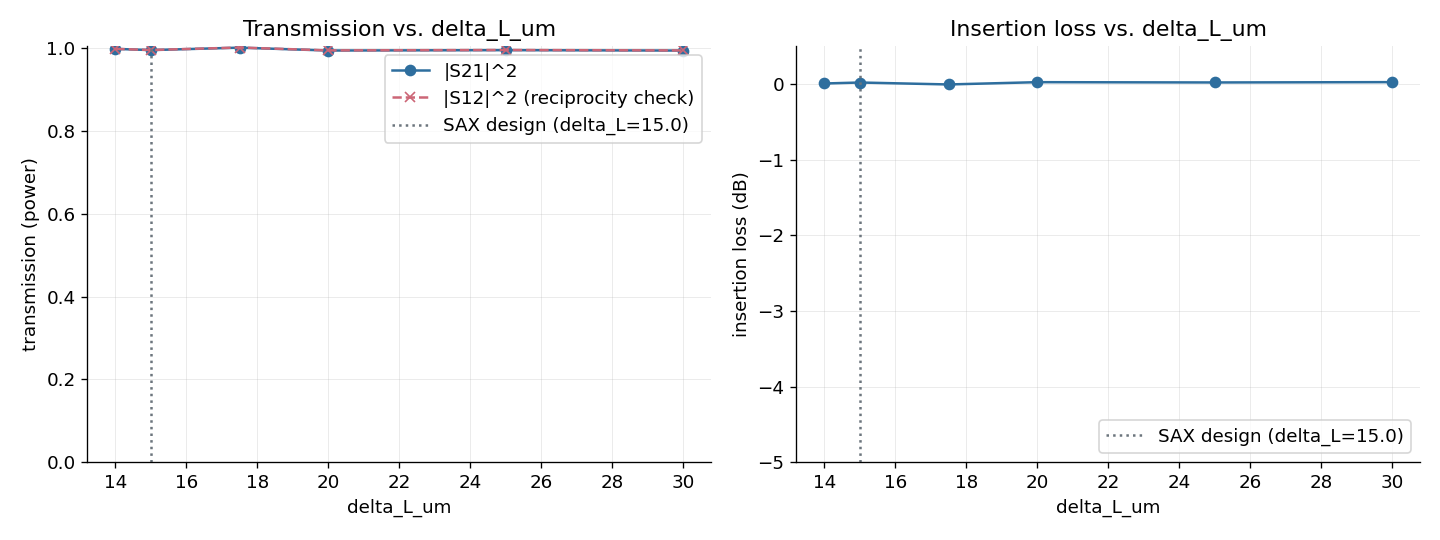

In [ ]:
delta_L_achieved = []
s21_center = []
s12_center = []
loss_db_center = []
reciprocity_diff = []

for dl_target, extra in zip(DELTA_L_SWEEP_UM, EXTRA_STRAIGHT_SWEEP_UM):
    # Matches sweep.grid_sweep's own tag construction exactly (k.replace("_um", "") + v).
    tag = f"extra_straight{extra}"
    a = sparams.load_artifact(Path("../data/sparams/mzi_arm/sweep") / f"mzi_arm_{tag}")
    mid = len(a.wavelengths_um) // 2
    s21 = a.s_matrix["21"][mid]
    s12 = a.s_matrix["12"][mid]
    delta_L_achieved.append(mzi_arm.delta_L_um_from_extra(a.metadata["swept_params"]["extra_straight_um"], params))
    s21_center.append(np.abs(s21) ** 2)
    s12_center.append(np.abs(s12) ** 2)
    loss_db_center.append(-10 * np.log10(np.abs(s21) ** 2))
    reciprocity_diff.append(np.abs(s21 - s12))

delta_L_achieved = np.array(delta_L_achieved)

fig, (ax_t, ax_l) = plt.subplots(1, 2, figsize=(12, 4.5))
ax_t.plot(delta_L_achieved, s21_center, "o-", color=style.COLOR_STEEL, label="|S21|^2")
ax_t.plot(delta_L_achieved, s12_center, "x--", color=style.COLOR_ROSE, label="|S12|^2 (reciprocity check)")
ax_t.axvline(15.0, color=style.COLOR_REFERENCE, ls=":", label="SAX design (delta_L=15.0)")
ax_t.set_xlabel("delta_L_um")
ax_t.set_ylabel("transmission (power)")
ax_t.set_title("Transmission vs. delta_L_um")
# Fixed (not auto-scaled) range: the underlying swing is <0.03dB across the whole
# sweep (see loss panel), so an auto-scaled axis would make ordinary FDTD numerical
# noise look like a large effect. This range makes the actual near-flat behavior visible.
ax_t.set_ylim(0, 1.005)
ax_t.legend()

ax_l.plot(delta_L_achieved, loss_db_center, "o-", color=style.COLOR_STEEL)
ax_l.axvline(15.0, color=style.COLOR_REFERENCE, ls=":", label="SAX design (delta_L=15.0)")
ax_l.set_xlabel("delta_L_um")
ax_l.set_ylabel("insertion loss (dB)")
ax_l.set_title("Insertion loss vs. delta_L_um")
ax_l.set_ylim(-5, 0.5)
ax_l.legend()
fig.tight_layout()
plt.show()

print("max |S21-S12| across the sweep (reciprocity):", max(reciprocity_diff))


## 12. Save sweep summary

The per-point artifacts saved by `grid_sweep()` in Section 10 are the detailed record.
For convenient downstream loading, this section also saves one consolidated `.npz`.

In [16]:
summary_path = Path("../data/sparams/mzi_arm/sweep/mzi_arm_sweep_summary.npz")
np.savez(
    summary_path,
    delta_L_um=delta_L_achieved,
    s21_power_center=np.array(s21_center),
    s12_power_center=np.array(s12_center),
    loss_db_center=np.array(loss_db_center),
)
print(f"Saved sweep summary: {summary_path}")


Saved sweep summary: ../data/sparams/mzi_arm/sweep/mzi_arm_sweep_summary.npz


---

## 13. Summary

Baseline validated at `extra_straight_um=0.864` (`delta_L_um=15.0`, matching the
SAX-designed lattice-filter notebook), and a `delta_L_um` sweep performed across
`14.0`-`30.0`um, bracketing that design point. Per-point artifacts live under
`data/sparams/mzi_arm/sweep/`, readable via `pic_toolkit.sparams.load_artifact`
without importing meep at all.

**Where this could go next (not built here):** a meep-free `models/mzi_arm.py` SAX
model (interpolating this component's cached S-parameters, same pattern as
`models/bend.py`), and swapping this jog geometry into `07_mzi.ipynb`'s full MZI in
place of the raised-cosine bump, to compare the two delay-arm geometries' loss at a
matched `delta_L_um`.